<a href="https://colab.research.google.com/github/coraagg/CDS526-Casestudy/blob/main/notebook/CF1_CTP_Runs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CF1, CTP1, CTP8 Experiments with AOS-NSGA-II and Fixed-Operator NSGA-II

**Author:** ZHANG Chenguo (Student ID: 5577723)  
**Date:** April 2026  
**Description:**  
This notebook runs 30 independent trials of the AOS-NSGA-II algorithm on CF1, CTP1, and CTP8 benchmark problems, and also runs the fixed-operator NSGA-II baseline for comparison. Results are saved as pickle files, and statistics (mean IGD, standard deviation, Wilcoxon test) are computed. LaTeX tables and convergence/Pareto plots are generated for reporting.

In [ ]:
# 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2: Install dependencies
!pip install pymoo matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.7 MB/s eta 0:00:00


In [ ]:
# 3: Clone code repository from GitHub
!git clone https://github.com/coraagg/CDS526-Casestudy.git
%cd CDS526-Casestudy

Cloning into 'CDS526-Casestudy'...
remote: Enumerating objects: 456, done.
remote: Counting objects: 100% (456/456), done.
remote: Compressing objects: 100% (437/437), done.
remote: Total 456 (delta 69), reused 39 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (456/456), 5.82 MiB | 8.63 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/CDS526-Casestudy


In [ ]:
# 4: Modify save path in run_experiments.py to Google Drive
import re

# Read the original file
with open('run_experiments.py', 'r', encoding='utf-8') as f:
    content = f.read()

# Replace default 'results' directory with Google Drive path
content = content.replace(
    "os.makedirs('results', exist_ok=True)",
    "os.makedirs('/content/drive/MyDrive/results', exist_ok=True)"
)
content = content.replace(
    "with open(f'results/{problem}_run_{run}.pkl', 'wb') as f:",
    "with open(f'/content/drive/MyDrive/results/{problem}_run_{run}.pkl', 'wb') as f:"
)
content = content.replace(
    "with open(f'results/{problem}_all.pkl', 'wb') as f:",
    "with open(f'/content/drive/MyDrive/results/{problem}_all.pkl', 'wb') as f:"
)
content = content.replace(
    "with open('results/all_results.pkl', 'wb') as f:",
    "with open('/content/drive/MyDrive/results/all_results.pkl', 'wb') as f:"
)

# Write back the modified file
with open('run_experiments.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("Save path modified to /content/drive/MyDrive/results")

Save path modified to /content/drive/MyDrive/results


In [ ]:
# 5: Run full experiments
import numpy as np
import random
from run_experiments import run_experiments

# Define complete problem list
problem_list = ['ctp8']

print("Problems to be executed:", problem_list)
print("Each problem: 30 independent runs, 200 generations, population size 100")
print("Results will be saved to /content/drive/MyDrive/results/")

# Run experiments (30 runs, 200 generations)
run_experiments(problem_list, n_runs=30, max_gen=200)

Problems to be executed: ['ctp8']
Each problem: 30 independent runs, 200 generations, population size 100
Results will be saved to /content/drive/MyDrive/results/

=== Running ctp8 ===
  Run 1/30


/usr/local/lib/python3.12/dist-packages/pymoo/problems/multi/ctp.py:36: RuntimeWarning: invalid value encountered in sqrt
  f2 = gg * (1 - (f1 / gg) ** 0.5)


Gen 50, IGD: 0.2840, Nondominated: 100
Gen 100, IGD: 0.2803, Nondominated: 100
Gen 150, IGD: 0.2800, Nondominated: 100
Gen 200, IGD: 0.2789, Nondominated: 100
  Run 2/30
Gen 50, IGD: 0.0055, Nondominated: 100
Gen 100, IGD: 0.0046, Nondominated: 100
Gen 150, IGD: 0.0049, Nondominated: 100
Gen 200, IGD: 0.0049, Nondominated: 100
  Run 3/30
Gen 50, IGD: 0.0066, Nondominated: 100
Gen 100, IGD: 0.0048, Nondominated: 100
Gen 150, IGD: 0.0046, Nondominated: 100
Gen 200, IGD: 0.0045, Nondominated: 100
  Run 4/30
Gen 50, IGD: 0.0060, Nondominated: 100
Gen 100, IGD: 0.0052, Nondominated: 100
Gen 150, IGD: 0.0052, Nondominated: 100
Gen 200, IGD: 0.0052, Nondominated: 100
  Run 5/30
Gen 50, IGD: 0.0196, Nondominated: 100
Gen 100, IGD: 0.0044, Nondominated: 100
Gen 150, IGD: 0.0046, Nondominated: 100
Gen 200, IGD: 0.0048, Nondominated: 100
  Run 6/30
Gen 50, IGD: 0.0064, Nondominated: 100
Gen 100, IGD: 0.0056, Nondominated: 100
Gen 150, IGD: 0.0053, Nondominated: 100
Gen 200, IGD: 0.0053, Nondomina

Saved convergence plot for cf1 to /content/drive/MyDrive/results/convergence_cf1.png
Saved convergence plot for ctp1 to /content/drive/MyDrive/results/convergence_ctp1.png
Saved convergence plot for ctp8 to /content/drive/MyDrive/results/convergence_ctp8.png


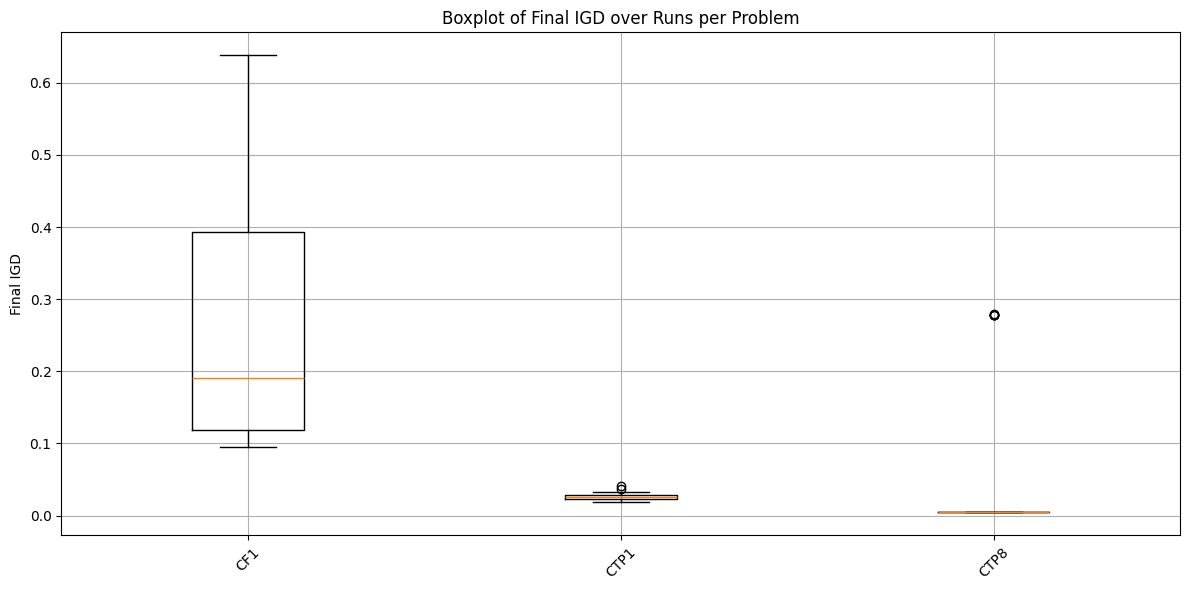

Saved boxplot to /content/drive/MyDrive/results/boxplot_all_problems.png


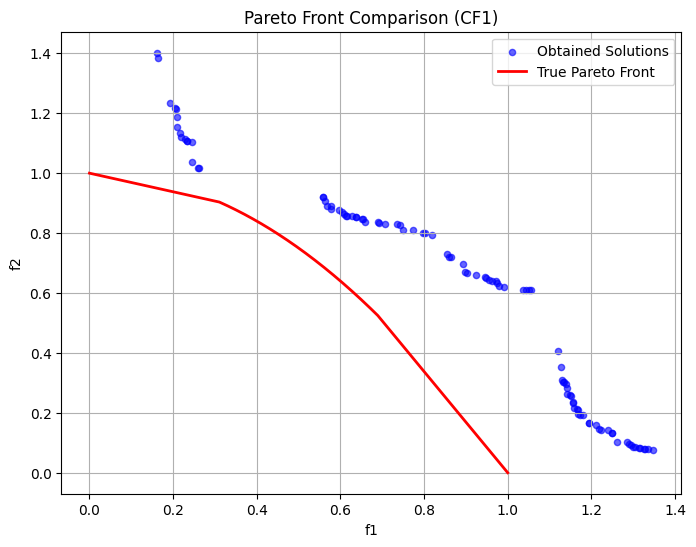

Saved Pareto plot to /content/drive/MyDrive/results/pareto_cf1.png


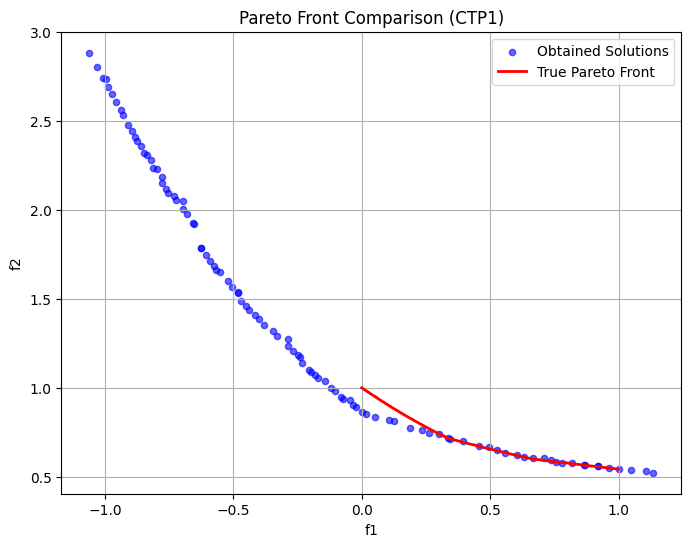

Saved Pareto plot to /content/drive/MyDrive/results/pareto_ctp1.png


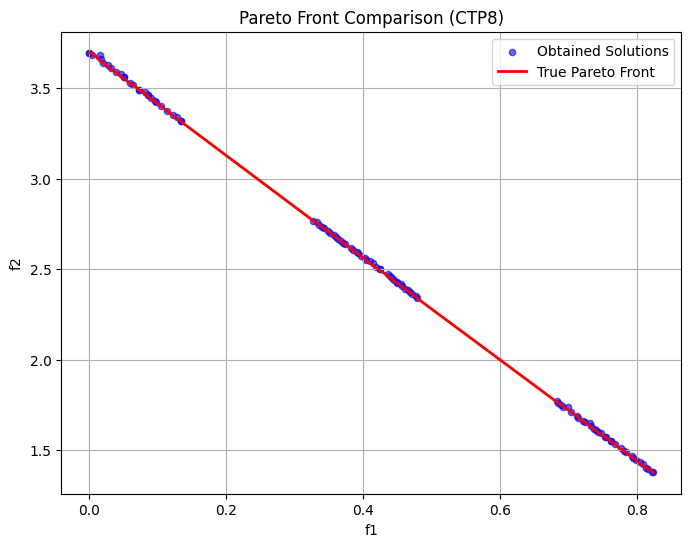

Saved Pareto plot to /content/drive/MyDrive/results/pareto_ctp8.png


In [ ]:
# 6: Draw figures
import visualize
visualize.plot_convergence_per_problem(all_results)
visualize.plot_boxplot_all_problems(all_results)
visualize.plot_all_pareto(all_results)

In [ ]:
# A: Define fixed-operator NSGA-II (derived from NSGA2_AOS)
import numpy as np
from nsga2_aos import NSGA2_AOS

class NSGA2_Fixed(NSGA2_AOS):
    def run_generation(self):
        action = 0  # always use Operator 0

        _, rank, crowding = self.non_dominated_sort(self.F, self.CV)
        parents = self.select_parents(self.pop, self.F, self.CV, rank, crowding, self.n_offsprings)
        offspring = self.reproduce(parents, action)

        F_off, G_off = self.problem.evaluate(offspring)
        CV_off = np.sum(np.maximum(0, G_off), axis=1)

        combined_pop = np.vstack([self.pop, offspring])
        combined_F = np.vstack([self.F, F_off])
        combined_CV = np.hstack([self.CV, CV_off])

        fronts, rank_comb, crowding_comb = self.non_dominated_sort(combined_F, combined_CV)

        new_pop = []
        new_F = []
        new_CV = []
        remaining = self.pop_size
        for front in fronts:
            if len(front) <= remaining:
                new_pop.extend(combined_pop[front])
                new_F.extend(combined_F[front])
                new_CV.extend(combined_CV[front])
                remaining -= len(front)
            else:
                front_crowding = crowding_comb[front]
                sorted_idx = np.argsort(front_crowding)[::-1]
                selected = [front[i] for i in sorted_idx[:remaining]]
                new_pop.extend(combined_pop[selected])
                new_F.extend(combined_F[selected])
                new_CV.extend(combined_CV[selected])
                break

        self.pop = np.array(new_pop)
        self.F = np.array(new_F)
        self.CV = np.array(new_CV)

        current_igd = self.compute_igd(self.F, self.CV)
        self.igd_history.append(current_igd)

        self.gen += 1
        if self.gen % 50 == 0:
            fronts, _, _ = self.non_dominated_sort(self.F, self.CV)
            nds = len(fronts[0]) if fronts else 0
            print(f"Gen {self.gen}, IGD: {current_igd:.4f}, Nondominated: {nds}")

In [ ]:
# B: Run fixed-operator experiments (CF1, CTP1, CTP8, 30 runs each)
import os
import pickle
import warnings
import numpy as np
import random
from problem import get_problem

def run_single_run_fixed(problem_name, run_id, pop_size=100, max_gen=200):
    seed = 42 + run_id
    np.random.seed(seed)
    random.seed(seed)

    problem = get_problem(problem_name)
    if problem.pareto_front() is None:
        warnings.warn(f"Problem {problem_name} has no true Pareto front.")
    algo = NSGA2_Fixed(problem, pop_size=pop_size, max_gen=max_gen)
    algo.run()
    return {
        'run': run_id,
        'problem': problem_name,
        'igd_history': algo.igd_history,
        'final_pop': algo.pop,
        'final_F': algo.F,
        'final_CV': algo.CV
    }

def run_fixed_experiments(problem_list, n_runs=30, max_gen=200, out_dir='results_fixed'):
    os.makedirs(out_dir, exist_ok=True)
    all_results = []
    for problem in problem_list:
        print(f"\n=== Running Fixed operator on {problem} ===")
        for run in range(n_runs):
            print(f"  Run {run+1}/{n_runs}")
            res = run_single_run_fixed(problem, run, max_gen=max_gen)
            all_results.append(res)
            with open(f'{out_dir}/{problem}_run_{run}.pkl', 'wb') as f:
                pickle.dump(res, f)
        problem_results = [r for r in all_results if r['problem'] == problem]
        with open(f'{out_dir}/{problem}_all.pkl', 'wb') as f:
            pickle.dump(problem_results, f)
    with open(f'{out_dir}/all_results.pkl', 'wb') as f:
        pickle.dump(all_results, f)
    print(f"\nFixed operator experiments saved to {out_dir}/")

# Run fixed-operator experiments (3 problems, 30 runs, 200 generations)
problem_list = ['cf1', 'ctp1', 'ctp8']   # Corrected problem names
run_fixed_experiments(problem_list, n_runs=30, max_gen=200, out_dir='results_fixed')


=== Running Fixed operator on cf1 ===
  Run 1/30
Gen 50, IGD: 0.5836, Nondominated: 89
Gen 100, IGD: 0.2902, Nondominated: 71
Gen 150, IGD: 0.1664, Nondominated: 100
Gen 200, IGD: 0.1348, Nondominated: 99
  Run 2/30
Gen 50, IGD: 0.5789, Nondominated: 61
Gen 100, IGD: 0.1752, Nondominated: 63
Gen 150, IGD: 0.1270, Nondominated: 100
Gen 200, IGD: 0.1057, Nondominated: 100
  Run 3/30
Gen 50, IGD: 0.5091, Nondominated: 60
Gen 100, IGD: 0.2662, Nondominated: 97
Gen 150, IGD: 0.2175, Nondominated: 96
Gen 200, IGD: 0.1876, Nondominated: 100
  Run 4/30
Gen 50, IGD: 0.6153, Nondominated: 69
Gen 100, IGD: 0.4784, Nondominated: 100
Gen 150, IGD: 0.2685, Nondominated: 100
Gen 200, IGD: 0.1711, Nondominated: 100
  Run 5/30
Gen 50, IGD: 0.5146, Nondominated: 58
Gen 100, IGD: 0.1757, Nondominated: 100
Gen 150, IGD: 0.1264, Nondominated: 92
Gen 200, IGD: 0.1177, Nondominated: 95
  Run 6/30
Gen 50, IGD: 0.7003, Nondominated: 51
Gen 100, IGD: 0.4560, Nondominated: 82
Gen 150, IGD: 0.3636, Nondominated:

/usr/local/lib/python3.12/dist-packages/pymoo/problems/multi/ctp.py:36: RuntimeWarning: invalid value encountered in sqrt
  f2 = gg * (1 - (f1 / gg) ** 0.5)


Gen 50, IGD: 0.2803, Nondominated: 100
Gen 100, IGD: 0.2793, Nondominated: 100
Gen 150, IGD: 0.2783, Nondominated: 100
Gen 200, IGD: 0.2780, Nondominated: 100
  Run 2/30
Gen 50, IGD: 0.2810, Nondominated: 100
Gen 100, IGD: 0.0057, Nondominated: 100
Gen 150, IGD: 0.0049, Nondominated: 100
Gen 200, IGD: 0.0044, Nondominated: 100
  Run 3/30
Gen 50, IGD: 0.0057, Nondominated: 100
Gen 100, IGD: 0.0045, Nondominated: 100
Gen 150, IGD: 0.0048, Nondominated: 100
Gen 200, IGD: 0.0045, Nondominated: 100
  Run 4/30
Gen 50, IGD: 0.0059, Nondominated: 100
Gen 100, IGD: 0.0049, Nondominated: 100
Gen 150, IGD: 0.0046, Nondominated: 100
Gen 200, IGD: 0.0045, Nondominated: 100
  Run 5/30
Gen 50, IGD: 0.0070, Nondominated: 100
Gen 100, IGD: 0.0044, Nondominated: 100
Gen 150, IGD: 0.0046, Nondominated: 100
Gen 200, IGD: 0.0044, Nondominated: 100
  Run 6/30
Gen 50, IGD: 0.1433, Nondominated: 100
Gen 100, IGD: 0.0048, Nondominated: 100
Gen 150, IGD: 0.0046, Nondominated: 100
Gen 200, IGD: 0.0047, Nondomina

In [ ]:
# C: Load AOS & fixed results from separate problem files, compute stats, Wilcoxon, and LaTeX table
import pickle
import numpy as np
import glob
import os
from scipy.stats import wilcoxon

# -------------------------------
# Load AOS results from Google Drive (each problem has its own *_all.pkl)
# -------------------------------
aos_results = []
aos_base_dir = '/content/drive/MyDrive/results'
for prob in ['cf1', 'ctp1', 'ctp8']:
    file_path = os.path.join(aos_base_dir, f'{prob}_all.pkl')
    with open(file_path, 'rb') as f:
        prob_results = pickle.load(f)
        aos_results.extend(prob_results)
print(f"Loaded {len(aos_results)} AOS records.")

# -------------------------------
# Load fixed-operator results (assuming they are also saved as separate *_all.pkl in results_fixed)
# -------------------------------
fixed_results = []
fixed_base_dir = 'results_fixed'
for prob in ['cf1', 'ctp1', 'ctp8']:
    file_path = os.path.join(fixed_base_dir, f'{prob}_all.pkl')
    with open(file_path, 'rb') as f:
        prob_results = pickle.load(f)
        fixed_results.extend(prob_results)
print(f"Loaded {len(fixed_results)} fixed-operator records.")

# -------------------------------
# Compute statistics and Wilcoxon test per problem
# -------------------------------
problems = ['cf1', 'ctp1', 'ctp8']
stats = {}

for prob in problems:
    aos_runs = [r for r in aos_results if r['problem'] == prob]
    fixed_runs = [r for r in fixed_results if r['problem'] == prob]
    aos_runs.sort(key=lambda x: x['run'])
    fixed_runs.sort(key=lambda x: x['run'])

    aos_igd = [r['igd_history'][-1] for r in aos_runs]
    fixed_igd = [r['igd_history'][-1] for r in fixed_runs]
    aos_feas = [(r['final_CV'] <= 0).mean() for r in aos_runs]
    fixed_feas = [(r['final_CV'] <= 0).mean() for r in fixed_runs]

    try:
        w_stat, p_value = wilcoxon(aos_igd, fixed_igd, alternative='less')
    except:
        p_value = np.nan

    stats[prob] = {
        'aos_igd': aos_igd, 'fixed_igd': fixed_igd,
        'aos_feas': aos_feas, 'fixed_feas': fixed_feas,
        'p_value': p_value
    }

    print(f"\n=== {prob.upper()} ===")
    print(f"AOS IGD mean±std: {np.mean(aos_igd):.4f} ± {np.std(aos_igd):.4f}")
    print(f"Fixed IGD mean±std: {np.mean(fixed_igd):.4f} ± {np.std(fixed_igd):.4f}")
    print(f"AOS Feas ratio: {np.mean(aos_feas):.3f} ± {np.std(aos_feas):.3f}")
    print(f"Fixed Feas ratio: {np.mean(fixed_feas):.3f} ± {np.std(fixed_feas):.3f}")
    print(f"Wilcoxon p-value (AOS < Fixed): {p_value:.4f}")

# -------------------------------
# Generate LaTeX table
# -------------------------------
latex = r"""
\begin{table}[H]
\centering
\caption{Performance comparison over 30 runs (mean ± std). Wilcoxon test (one-sided, AOS < Fixed).}
\label{tab:comparison}
\begin{tabular}{lcccccc}
\hline
Problem & Method & IGD & Feasible Ratio & p-value \\
\hline
"""
for prob in problems:
    aos_igd_m = np.mean(stats[prob]['aos_igd'])
    aos_igd_s = np.std(stats[prob]['aos_igd'])
    fixed_igd_m = np.mean(stats[prob]['fixed_igd'])
    fixed_igd_s = np.std(stats[prob]['fixed_igd'])
    aos_feas_m = np.mean(stats[prob]['aos_feas'])
    aos_feas_s = np.std(stats[prob]['aos_feas'])
    fixed_feas_m = np.mean(stats[prob]['fixed_feas'])
    fixed_feas_s = np.std(stats[prob]['fixed_feas'])
    p = stats[prob]['p_value']
    sig = ''
    if p < 0.001: sig = '***'
    elif p < 0.01: sig = '**'
    elif p < 0.05: sig = '*'

    latex += f"""
\\multirow{{2}}{{*}}{{{prob.upper()}}} & AOS-NSGA-II & {aos_igd_m:.3f} ± {aos_igd_s:.3f} & {aos_feas_m:.3f} ± {aos_feas_s:.3f} & {p:.3f}{sig} \\\\
 & Fixed-NSGA-II & {fixed_igd_m:.3f} ± {fixed_igd_s:.3f} & {fixed_feas_m:.3f} ± {fixed_feas_s:.3f} & \\\\
\hline
"""
latex += r"""
\end{tabular}
\end{table}
"""
print(latex)
with open('comparison_table.tex', 'w') as f:
    f.write(latex)
print("Table saved to comparison_table.tex")

<>:100: SyntaxWarning: invalid escape sequence '\h'
<>:100: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_922/1497371608.py:100: SyntaxWarning: invalid escape sequence '\h'
  latex += r"""


Loaded 90 AOS records.
Loaded 90 fixed-operator records.

=== CF1 ===
AOS IGD mean±std: 0.2581 ± 0.1679
Fixed IGD mean±std: 0.1958 ± 0.0733
AOS Feas ratio: 1.000 ± 0.000
Fixed Feas ratio: 1.000 ± 0.000
Wilcoxon p-value (AOS < Fixed): 0.8689

=== CTP1 ===
AOS IGD mean±std: 0.0261 ± 0.0046
Fixed IGD mean±std: 0.0505 ± 0.0146
AOS Feas ratio: 1.000 ± 0.000
Fixed Feas ratio: 1.000 ± 0.000
Wilcoxon p-value (AOS < Fixed): 0.0000

=== CTP8 ===
AOS IGD mean±std: 0.0504 ± 0.1021
Fixed IGD mean±std: 0.0502 ± 0.1022
AOS Feas ratio: 1.000 ± 0.000
Fixed Feas ratio: 1.000 ± 0.000
Wilcoxon p-value (AOS < Fixed): 0.9950

\begin{table}[H]
\centering
\caption{Performance comparison over 30 runs (mean ± std). Wilcoxon test (one-sided, AOS < Fixed).}
\label{tab:comparison}
\begin{tabular}{lcccccc}
\hline
Problem & Method & IGD & Feasible Ratio & p-value \\
\hline

\multirow{2}{*}{CF1} & AOS-NSGA-II & 0.258 ± 0.168 & 1.000 ± 0.000 & 0.869 \\
 & Fixed-NSGA-II & 0.196 ± 0.073 & 1.000 ± 0.000 & \\
\hline

\mul